# KITTY FILE

Here I test the functions for the KITTY dataset to make sure they work and don't produce any errors in further stages of the poject. Also, I make
some visualizations to better show the file contents and the results.

In [1]:
from utils import getDevice #important to impot at the start for reproducibility :3 

Using device: xpu :3
Setting seed to 42:3


In [2]:
# GENERAL IMPORTS
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import time
import torch
import gc
import os

# CUSTIM FUNCTIONS AND VARIABLES
from kitty import depth_read, listPicsWith, togglePath, MatchDepthToCar, KITTY_PATH
from yolo import getEmbedFromResults, getCropsFromResults, getCropsFromResult, getEmbedFromCrops, CLASSES_YOLO, CONFIDENCE_YOLO

# YOLO STUFF
from ultralytics import YOLO

#DINO STUFF
from transformers import AutoImageProcessor, AutoModel
from transformers.image_utils import load_image

YOLO26n MODEL LOADED



Device is identified to be used for GPU acceleration. If not possible CPU is used.

In [3]:
device = getDevice()

Firstly, I wanted to take a look at the data presented. It is stored in 2 files: one with color image and one with depth info that is read using a special 
function provided in dev tools.

The code below shows the results. Error points, where value is negative and thus no depth is present are omitted.

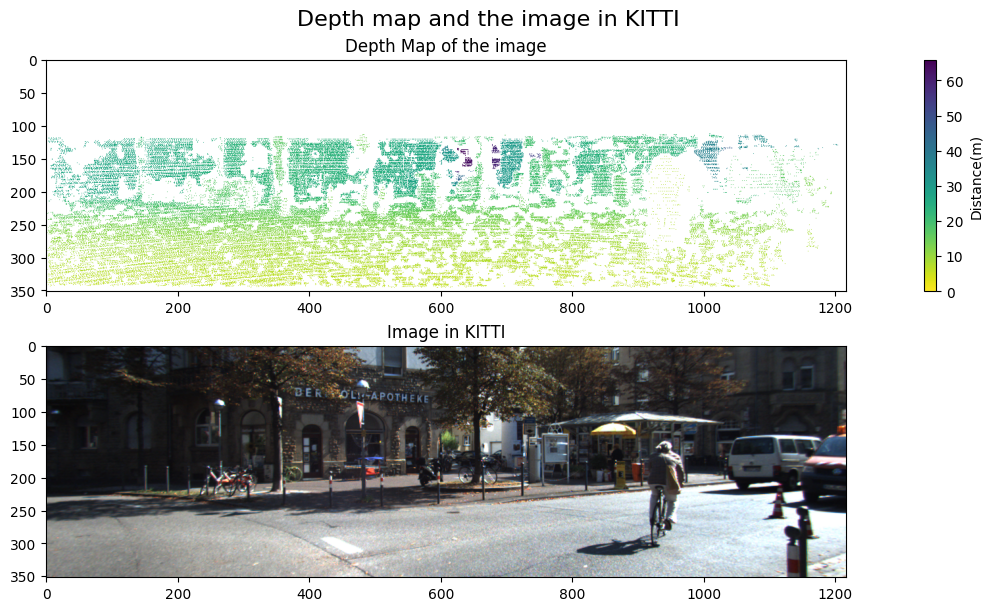

9019

In [6]:
depth_map = "../datasets/depth_selection/val_selection_cropped/groundtruth_depth/2011_09_26_drive_0005_sync_groundtruth_depth_0000000071_image_03.png"
depth_map_img = togglePath(depth_map)

depth_img = np.array(Image.open(depth_map_img), dtype=int)

depth_np = depth_read(depth_map)

cmap = plt.cm.viridis_r.copy()
cmap.set_under('white')   # values below vmin
cmap.set_over('white') 

fig, ax = plt.subplots(2, 1, figsize=(10, 6), constrained_layout=True)

# First image
im = ax[0].imshow(depth_np, cmap=cmap, vmin=0)
fig.colorbar(im, ax=ax[0]).set_label("Distance(m)")
ax[0].set_title("Depth Map of the image")
ax[0].set_anchor('C')   # center image

# Second image
ax[1].imshow(depth_img)
ax[1].set_title("Image in KITTI")
ax[1].set_anchor('C')   # center image

plt.suptitle("Depth map and the image in KITTI", fontsize=16)
plt.show()

fig.savefig("../visualizations/depthmap_vs_image_kitty.png", dpi=300)

del depth_map, depth_map_img, depth_img, depth_np, cmap, fig, ax, im
gc.collect()

## Extracting true depth from an image

1. Find all images with cars in them with over 50% certainty
2. Use YOLO to find bounding boxes for each image
3. For each image:
    1. crop the depth image to the car bounding box
    2. convert depth using devkit function to m from image
    4. drop the invalid points (where depth is -1)
    3. compute exact value either as average or RANSACK fitted value in the middle of the image

Both avergaes and ransac predictions in the middle are stored in a numpy array for further visualizations

## Extracting embeddings

For each batch of images an array of crops is retrived and then processed together. This is done to balance speed and memory usage. Larger batches can lead to 
faster processing, but larger memory use. 

In [5]:
images_with_cars = listPicsWith(KITTY_PATH, CLASSES_YOLO, CONFIDENCE_YOLO, True)
gc.collect()

1000
2011_09_26_drive_0002_sync_image_0000000005_image_02.png
../datasets/depth_selection/val_selection_cropped/image/2011_09_26_drive_0002_sync_image_0000000005_image_02.png

0: 192x640 (no detections), 9.1ms
1: 192x640 (no detections), 9.1ms
2: 192x640 (no detections), 9.1ms
3: 192x640 (no detections), 9.1ms
4: 192x640 (no detections), 9.1ms
5: 192x640 (no detections), 9.1ms
6: 192x640 (no detections), 9.1ms
7: 192x640 (no detections), 9.1ms
8: 192x640 (no detections), 9.1ms
9: 192x640 (no detections), 9.1ms
10: 192x640 (no detections), 9.1ms
11: 192x640 (no detections), 9.1ms
12: 192x640 (no detections), 9.1ms
13: 192x640 (no detections), 9.1ms
14: 192x640 (no detections), 9.1ms
15: 192x640 (no detections), 9.1ms
16: 192x640 (no detections), 9.1ms
17: 192x640 (no detections), 9.1ms
18: 192x640 (no detections), 9.1ms
19: 192x640 (no detections), 9.1ms
20: 192x640 (no detections), 9.1ms
21: 192x640 1 car, 9.1ms
22: 192x640 1 car, 9.1ms
23: 192x640 1 car, 9.1ms
24: 192x640 1 car, 9.1ms

0

This section uses YOLO to get the forward pass data and based on that for each object find its true depth as well as embeddings.

In [6]:
model = YOLO("../build/yolo26n.pt").to(device)
torch.xpu.empty_cache()
gc.collect()

11

In [7]:
CHUNK_SIZE = 50
ransac_preds_combined = np.array([])
avgs_combined = np.array([])

embed_paths = []
chunk=[]
chunk_count = 0

print("Now we process images 1 by 1")
processed= 0

for i in range(len(images_with_cars)//CHUNK_SIZE + 1):
    images = images_with_cars[i*CHUNK_SIZE:(i+1)*CHUNK_SIZE]
    processed +=len(images)

    print(f"Progres: {i/(len(images_with_cars)//CHUNK_SIZE + 1)*100:.2f}%")

    #YOLO FORWARD PASS
    results = model.predict(images, conf=CONFIDENCE_YOLO, classes=CLASSES_YOLO, verbose=False)

    #DEPTH IS RETRIEVED
    for i, result in enumerate(results):
        ransac_preds, avgs = MatchDepthToCar(images[i], result)
        ransac_preds_combined = np.append(ransac_preds_combined, ransac_preds)
        avgs_combined = np.append(avgs_combined, avgs)
    
    #YOLO EMBEDS
    crops = getCropsFromResults(results)
    if crops:
        embeds = getEmbedFromCrops(crops)
        #move the chunks to the cpu
        for em in embeds:
            chunk.append(em.cpu())

        #flush the batch into the memory
        chumky_path = f"../data/yolo_embeds_chunk_{chunk_count}.pt"
        torch.save(torch.stack(chunk), chumky_path)
        #save the path
        embed_paths.append(chumky_path)

        #clean up the mess
        del chunk
        chunk = []
        chunk_count += 1

        del crops, embeds
    #let's tidy up the mess :3
    del results
    torch.xpu.empty_cache()
    gc.collect()

print(f"processed: {processed} images and total should be {len(images_with_cars)}")

Now we process images 1 by 1
Progres: 0.00%

Progres: 6.25%

Progres: 12.50%

Progres: 18.75%
EMPTY SLICE OF THE IMAGE, NO DEPTH :(
EMPTY SLICE OF THE IMAGE, NO DEPTH :(

Progres: 25.00%

Progres: 31.25%
EMPTY SLICE OF THE IMAGE, NO DEPTH :(

Progres: 37.50%
EMPTY SLICE OF THE IMAGE, NO DEPTH :(

Progres: 43.75%

Progres: 50.00%

Progres: 56.25%

Progres: 62.50%

Progres: 68.75%

Progres: 75.00%

Progres: 81.25%

Progres: 87.50%

Progres: 93.75%

processed: 772 images and total should be 772


In order to make sure that the YOLO embeddings are a single file a merge is performed.

In [8]:
print("Merging YOLO embedding chunks...")
all_chunks = [torch.load(p) for p in embed_paths]
full_embeds = torch.cat(all_chunks, dim=0)
torch.save(full_embeds, "../data/embeds_yolo.pt")
print(f"Saved YOLO embeddings: {full_embeds.shape}")
del all_chunks, full_embeds
gc.collect()

for path in embed_paths:
    os.remove(path)

Merging YOLO embedding chunks...
Saved YOLO embeddings: torch.Size([2566, 256])


Depth measurements are analyzed in this section

In [9]:
ratios_combined = (ransac_preds_combined-avgs_combined)/avgs_combined *100
ratios_combined_inv = (avgs_combined-ransac_preds_combined)/ransac_preds_combined *100

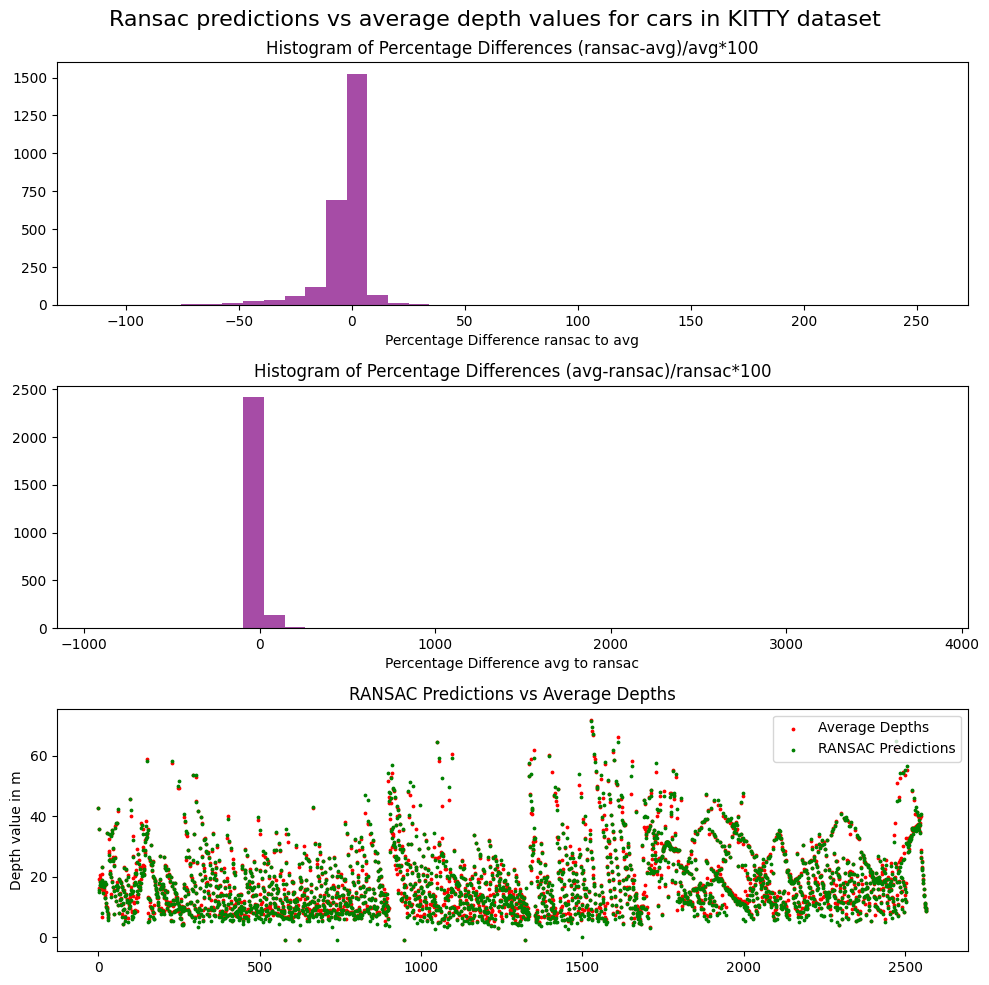

In [10]:
fig, ax = plt.subplots(nrows=3, ncols=1,figsize=(10, 10))

axes = ax.flatten()

axes[0].hist(ratios_combined, bins=40, color='purple', alpha=0.7)
axes[0].set_title('Histogram of Percentage Differences (ransac-avg)/avg*100')
axes[0].set_xlabel('Percentage Difference ransac to avg')

axes[1].hist(ratios_combined_inv, bins=40, color='purple', alpha=0.7)
axes[1].set_title('Histogram of Percentage Differences (avg-ransac)/ransac*100')
axes[1].set_xlabel('Percentage Difference avg to ransac')

indicies = np.arange(len(ratios_combined))
axes[2].scatter(indicies, avgs_combined, color='red', label='Average Depths', s=3)
axes[2].scatter(indicies, ransac_preds_combined, color='green', label='RANSAC Predictions',s=3)
axes[2].set_title('RANSAC Predictions vs Average Depths')
axes[2].set_ylabel("Depth value in m")

plt.suptitle("Ransac predictions vs average depth values for cars in KITTY dataset", fontsize=16)
plt.tight_layout()
plt.legend()
plt.show()

fig.savefig("../visualizations/ransac_vs_avg.png", dpi=300)

In [11]:
#conversion to tensors
ransac_tensor = torch.from_numpy(ransac_preds_combined).float()
torch.save(ransac_tensor, "../data/ransac_depth.pt")
del ransac_tensor
gc.collect()

avgs_tensor = torch.from_numpy(avgs_combined).float()
torch.save(avgs_tensor, "../data/avgs_depth.pt")
del avgs_tensor
gc.collect()

del ratios_combined, ratios_combined_inv, indicies, fig, ax, axes, ransac_preds_combined, avgs_combined
gc.collect()

14425

Dino embeddings are retrieved

In [12]:
DINO_MODEL_ID = "facebook/dinov3-vits16-pretrain-lvd1689m"

image_processor = AutoImageProcessor.from_pretrained(DINO_MODEL_ID)
dinov3 = AutoModel.from_pretrained(
    DINO_MODEL_ID,
    dtype=torch.float16,
    device_map="auto"
).to(device)

def get_embedding(image):
    """
    Get DINOv3 embeddings from an image or a list of images. 
    Args:
        image: string path or PIL image or list of ready to pricess opened imaged
    """
    #case 1 - image is a path
    if type(image) == str:
        image = load_image(image)
    
    #case 2 is pil image already or compatible with the class
    inputs = image_processor(images=image, return_tensors="pt").to(device)

    #retrieve embeddings
    dinov3.eval()
    with torch.inference_mode():
        outputs = dinov3(**inputs)

    return outputs.pooler_output  # final embeddings

Loading weights: 100%|██████████| 211/211 [00:00<00:00, 1397.92it/s]


In [13]:
CHUNK_SIZE = 50

embed_paths_dino = []
chunk=[]
chunk_count = 0
processed= 0

for i in range(len(images_with_cars)//CHUNK_SIZE + 1):
    images = images_with_cars[i*CHUNK_SIZE:(i+1)*CHUNK_SIZE]
    processed +=len(images)

    print(f"Progres: {i/(len(images_with_cars)//CHUNK_SIZE + 1)*100:.2f}%")

    #YOLO FORWARD PASS
    results = model.predict(images, conf=CONFIDENCE_YOLO, classes=CLASSES_YOLO, verbose=False)
    
    #DINO EMBEDS
    crops = getCropsFromResults(results)
    if crops:
        embeds = get_embedding(crops)
        #move the chunks to the cpu
        for em in embeds:
            chunk.append(em.cpu())

        #flush the batch into the memory
        chumky_path = f"../data/dino_embeds_chunk_{chunk_count}.pt"
        torch.save(torch.stack(chunk), chumky_path)
        #save the path
        embed_paths_dino.append(chumky_path)

        #clean up the mess
        del chunk
        chunk = []
        chunk_count += 1

        del crops, embeds
    #let's tidy up the mess :3
    del results
    torch.xpu.empty_cache()
    gc.collect()

print(f"processed: {processed} images and total should be {len(images_with_cars)}")

Progres: 0.00%
Progres: 6.25%
Progres: 12.50%
Progres: 18.75%
Progres: 25.00%
Progres: 31.25%
Progres: 37.50%
Progres: 43.75%
Progres: 50.00%
Progres: 56.25%
Progres: 62.50%
Progres: 68.75%
Progres: 75.00%
Progres: 81.25%
Progres: 87.50%
Progres: 93.75%
processed: 772 images and total should be 772


In [14]:
print("Merging DINO embedding chunks...")
all_chunks = [torch.load(p) for p in embed_paths_dino]
full_embeds = torch.cat(all_chunks, dim=0)
torch.save(full_embeds, "../data/embeds_dino.pt")
print(f"Saved DINO embeddings: {full_embeds.shape}")
del all_chunks, full_embeds
gc.collect()

for path in embed_paths_dino:
    os.remove(path)

Merging DINO embedding chunks...
Saved DINO embeddings: torch.Size([2566, 384])


## Depths are retrieved from the bounding boxes and depth maps

In [15]:
# start = time.time()
# #RESULTS VARIABLES ARE PREPARED



# #LOOP FOR EVERY IMAGE
# print("\nCALCULATING DEPTH:")
# for i, image_path in enumerate(images_with_cars):
#     #progress is printed
#     if i % 100 == 0:
#         print(f"Progress: {i/len(images_with_cars)*100:.2f}%")
#     #i fetch current result
#     result = results[i]

#     #DEPTH IS RETRIEVED
#     ransac_preds, avgs = MatchDepthToCar(image_path, result)

#     ransac_preds_combined = np.append(ransac_preds_combined, ransac_preds)
#     avgs_combined = np.append(avgs_combined, avgs)

# #initial data types
# print(f"TYPES:\nRANSAC: {type(ransac_preds_combined)};\nAVGS: {type(avgs_combined)};")

# #conversion to tensors
# ransac_tensor = torch.from_numpy(ransac_preds_combined).float()
# torch.save(ransac_tensor, "../data/ransac_depth.pt")
# del ransac_tensor
# gc.collect()

# avgs_tensor = torch.from_numpy(avgs_combined).float()
# torch.save(avgs_tensor, "../data/avgs_depth.pt")
# del avgs_tensor
# gc.collect()

# end = time.time()
# print(f"Total time taken to find depths: {end - start:.2f} seconds")


In [16]:
# Source - https://stackoverflow.com/q/47447270
# Posted by user3226167, modified by community. See post 'Timeline' for change history
# Retrieved 2026-04-13, License - CC BY-SA 3.0

#abc.py
def lsos(all_obj = globals(),n=10):

    import sys

    object_name = list(all_obj)
    object_size = [ round(sys.getsizeof(all_obj[x])/1024.0/1024.0,4) for x in object_name]
    object_id = [id(all_obj[x]) for x in object_name]

    d = [(a,b,c) for a,b,c in zip(object_name, object_size, object_id)]
    d.sort(key = lambda x:(x[1],x[2]), reverse=True)
    dprint = d[0:min(len(d), n)]

    #print formating
    name_width_max = max([len(x[0]) for x in dprint])
    print(("{:<" + str(name_width_max +2) + "}{:11}{}").format("name","size_Mb","id"))
    fmt = '{{:<{}}}'.format(name_width_max+2) +"  "+ "{: 5.4f}" +"  "+ "{:d}"
    for line in dprint:
        print( fmt.format(*line))

    return

print("Top 20 objects in memory:")
lsos(n=20)
print("Top 20 objects in memory local:")
lsos(locals(), n=20)


Top 20 objects in memory:
name                size_Mb    id
images_with_cars       0.0066  139722602266048
AutoModel              0.0016  94845839870672
AutoImageProcessor     0.0016  94845839837728
YOLO                   0.0016  94845769430928
_i7                    0.0015  94849138799952
_iii                   0.0011  94849249095440
_i13                   0.0011  94849249095440
_i                     0.0011  94847334098864
_i15                   0.0011  94847334098864
_i10                   0.0010  94849241035648
_i16                   0.0010  94847337170048
_i4                    0.0009  94845832827536
_i12                   0.0008  94849240084432
_i2                    0.0006  94845550276432
_ii                    0.0004  139726971117488
_i14                   0.0004  139726971117488
_i11                   0.0004  94849518073488
_i8                    0.0003  139722057610800
open                   0.0002  139727142445024
getDevice              0.0002  139726967433776
Top 20 objects

In [17]:
# #EMBEDDINGS ARE RETRIEVED
# embeds_yolo=[]
# embeds_dino=[]

# #embeds_yolo = getEmbedFromResults(results)
# crops = getCropsFromResults(results)
# print("\nEXTRACTING YOLO EMBEDDINGS:")
# start = time.time()
# embeds_yolo = getEmbedFromCrops(crops)
# end = time.time()
# print(f"Total time taken for YOLO embeddings extraction: {end - start:.2f} seconds")
# print("\nEXTRACTING DINO EMBEDDINGS:")
# start = time.time()
# embeds_dino = get_embedding(crops)
# end = time.time()
# print(f"Total time taken for DINO embeddings extraction: {end - start:.2f} seconds")

# del crops
# gc.collect()

# #WE NOW HOW THE TOTAL RESULTS FOR THE IMAGES
# print(f"SHAPES:\nRANSAC {ransac_preds_combined.shape};\nAVGS: {avgs_combined.shape};\n")

Saving the final results to a file as a torch tensor

In [18]:
# embeds_tensor = torch.stack(embeds_list)
# torch.save(embeds_tensor, "../data/embeds_yolo.pt")
# del embeds_yolo, embeds_tensor
# gc.collect()
#torch.empty_cache()

In [19]:
# Verify saved files by reloading
ransac_check = torch.load("../data/ransac_depth.pt")
avgs_check   = torch.load("../data/avgs_depth.pt")
embeds_check = torch.load("../data/embeds_yolo.pt")

print(f"SHAPES:\nRANSAC: {ransac_check.shape}\nAVGS: {avgs_check.shape}\nEMBEDS: {embeds_check.shape}")

del ransac_check, avgs_check, embeds_check

SHAPES:
RANSAC: torch.Size([2566])
AVGS: torch.Size([2566])
EMBEDS: torch.Size([2566, 256])


In [20]:
# torch.save(embeds_dino, "../data/embeds_dino.pt")
# del embeds_dino
# gc.collect()